# P1 vs. P1 Venn Diagram of DEGs
using results from [deseq_p1.v.p1.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase1_v_phase1/deseq_p1.v.p1.ipynb) to look for DEGs that are shared/unique among the comparisons

## 0. load libraries

In [2]:
library(ggvenn)
library(tidyverse)
library(UpSetR)

## 1. read CSVs

In [3]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq',
    pattern = '\\.csv$',
    full.names = TRUE
    )

head(files)

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1_vst.csv"        
[2] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.both_v_cont.csv"
[3] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_both.csv" 
[4] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_cont.csv" 
[5] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.hyp_v_warm.csv" 
[6] "/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/new_refGenome/deseq_res/prefilter_deseq/p1.warm_v_both.csv"

In [12]:
names(files) <- gsub("p1.", "", tools::file_path_sans_ext(basename(files)))
file_list <- lapply(files, read.csv)
names(file_list)

[1] "vst"         "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm" 
[6] "warm_v_both" "warm_v_cont"

In [13]:
file_list$vst <- NULL

In [14]:
p1.deg <- lapply(file_list, function(df) {
  df %>% filter(abs(log2FoldChange) >= "1" & padj <= 0.05)
})

names(p1.deg)
head(p1.deg$both_v_cont)

[1] "both_v_cont" "hyp_v_both"  "hyp_v_cont"  "hyp_v_warm"  "warm_v_both"
[6] "warm_v_cont"

,X,baseMean,log2FoldChange,lfcSE,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111120925,191.44305,-4.896465,1.409247,8.354541e-06,0.003583072
2,LOC111103173,15.14959,4.218014,2.190355,7.946660e-05,0.015793826
3,LOC111105159,57.17908,-5.230651,2.548703,4.742151e-05,0.010936474
4,LOC111132252,110.19476,-2.652259,2.036190,2.797628e-04,0.035210225
5,LOC111137262,591.06709,3.699058,3.002475,2.185576e-04,0.029884818
6,LOC111105069,273.29807,-3.772801,2.837354,1.914828e-04,0.027103700


## 2. venn diagram

#### comparisons against control

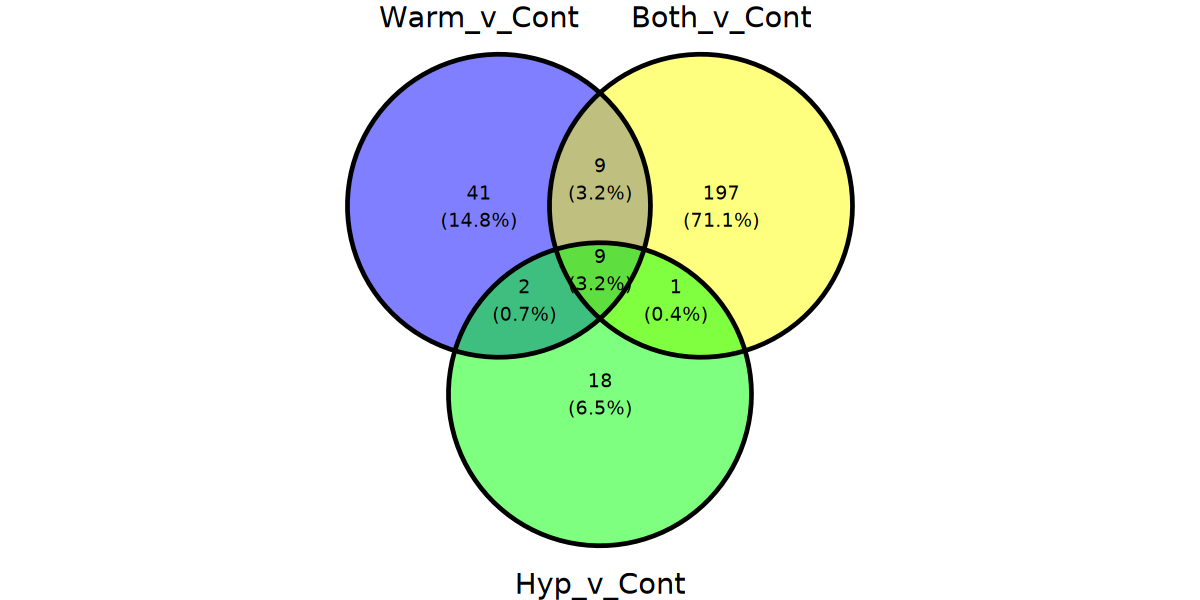

In [16]:
options(repr.plot.width=10, repr.plot.height=5)

# make list of dfs
x = list(Warm_v_Cont = p1.deg$warm_v_cont$X,
         Both_v_Cont = p1.deg$both_v_cont$X,
         Hyp_v_Cont = p1.deg$hyp_v_cont$X)

ggvenn(x)

#### comparisons with warm

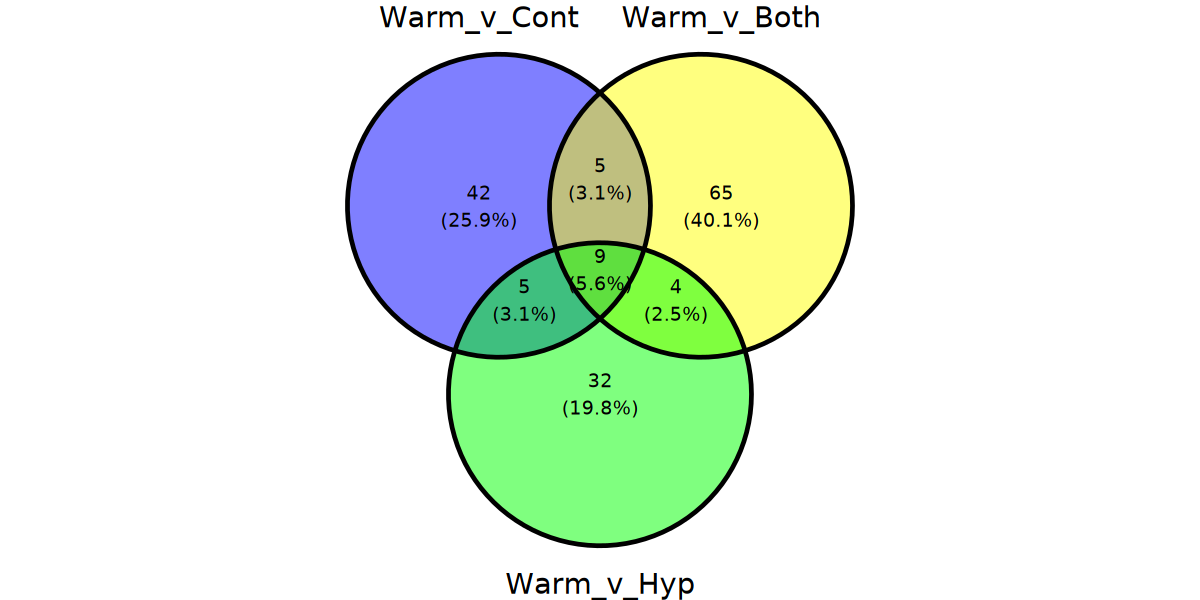

In [18]:
# make list of dfs
y = list(Warm_v_Cont = p1.deg$warm_v_cont$X,
         Warm_v_Both = p1.deg$warm_v_both$X,
         Warm_v_Hyp = p1.deg$hyp_v_warm$X)

ggvenn(y)

#### comparisons with hypoxic

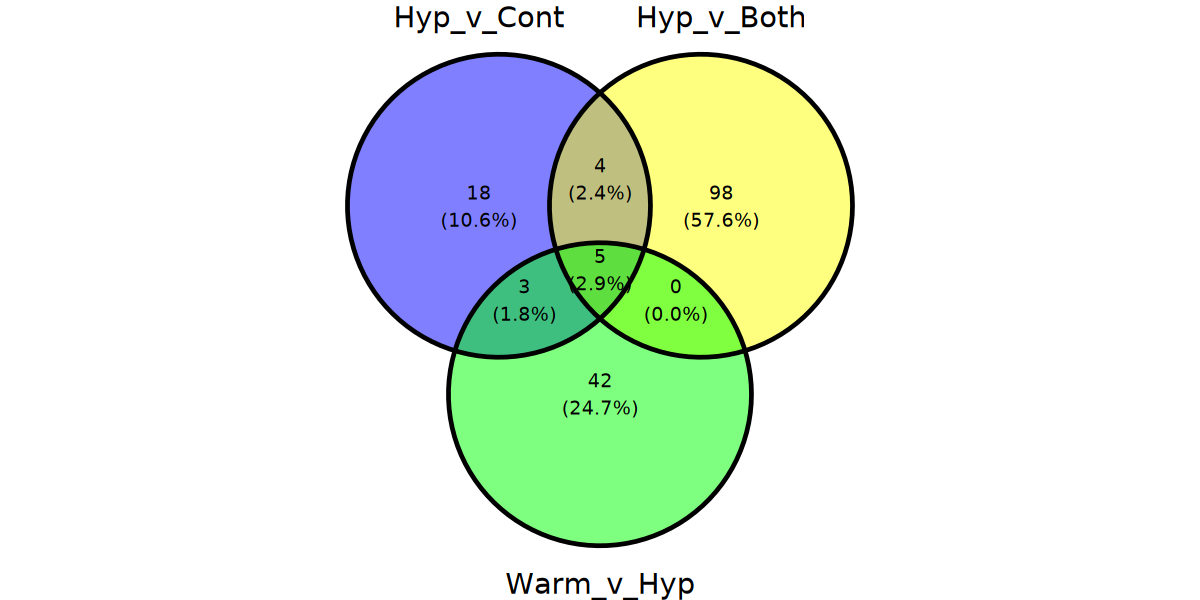

In [19]:
# make list of dfs
z = list(Hyp_v_Cont = p1.deg$hyp_v_cont$X,
         Hyp_v_Both = p1.deg$hyp_v_both$X,
         Warm_v_Hyp = p1.deg$hyp_v_warm$X)

ggvenn(z)

#### comparisons with both

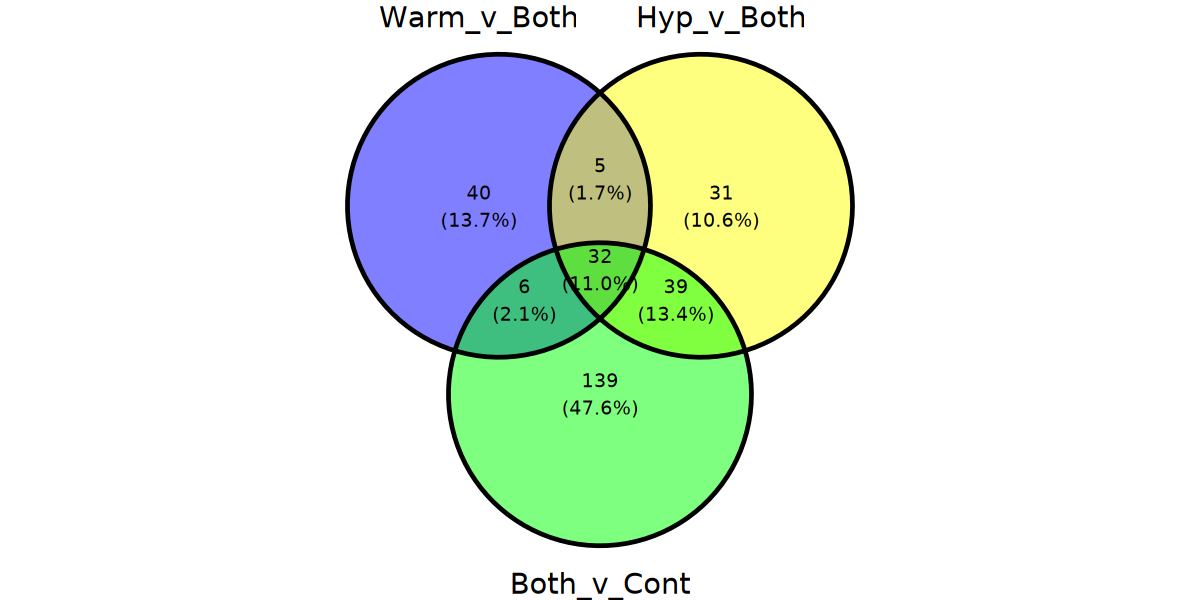

In [20]:
# make list of dfs
w = list(Warm_v_Both = p1.deg$warm_v_both$X,
         Hyp_v_Both = p1.deg$hyp_v_both$X,
         Both_v_Cont = p1.deg$both_v_cont$X)

ggvenn(w)

## Upset Plot
similar to venn diagram, but different type of visual

using [`UpSetR`](https://github.com/hms-dbmi/UpSetR)

In [21]:
# make list of dfs
u_list = list(Warm_v_Cont = p1.deg$warm_v_cont$X,
         Both_v_Cont = p1.deg$both_v_cont$X,
         Hyp_v_Cont = p1.deg$hyp_v_cont$X,
        Hyp_v_Both = p1.deg$hyp_v_both$X,
        Warm_v_Both = p1.deg$warm_v_both$X,
        Hyp_v_Warm = p1.deg$hyp_v_warm$X)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”


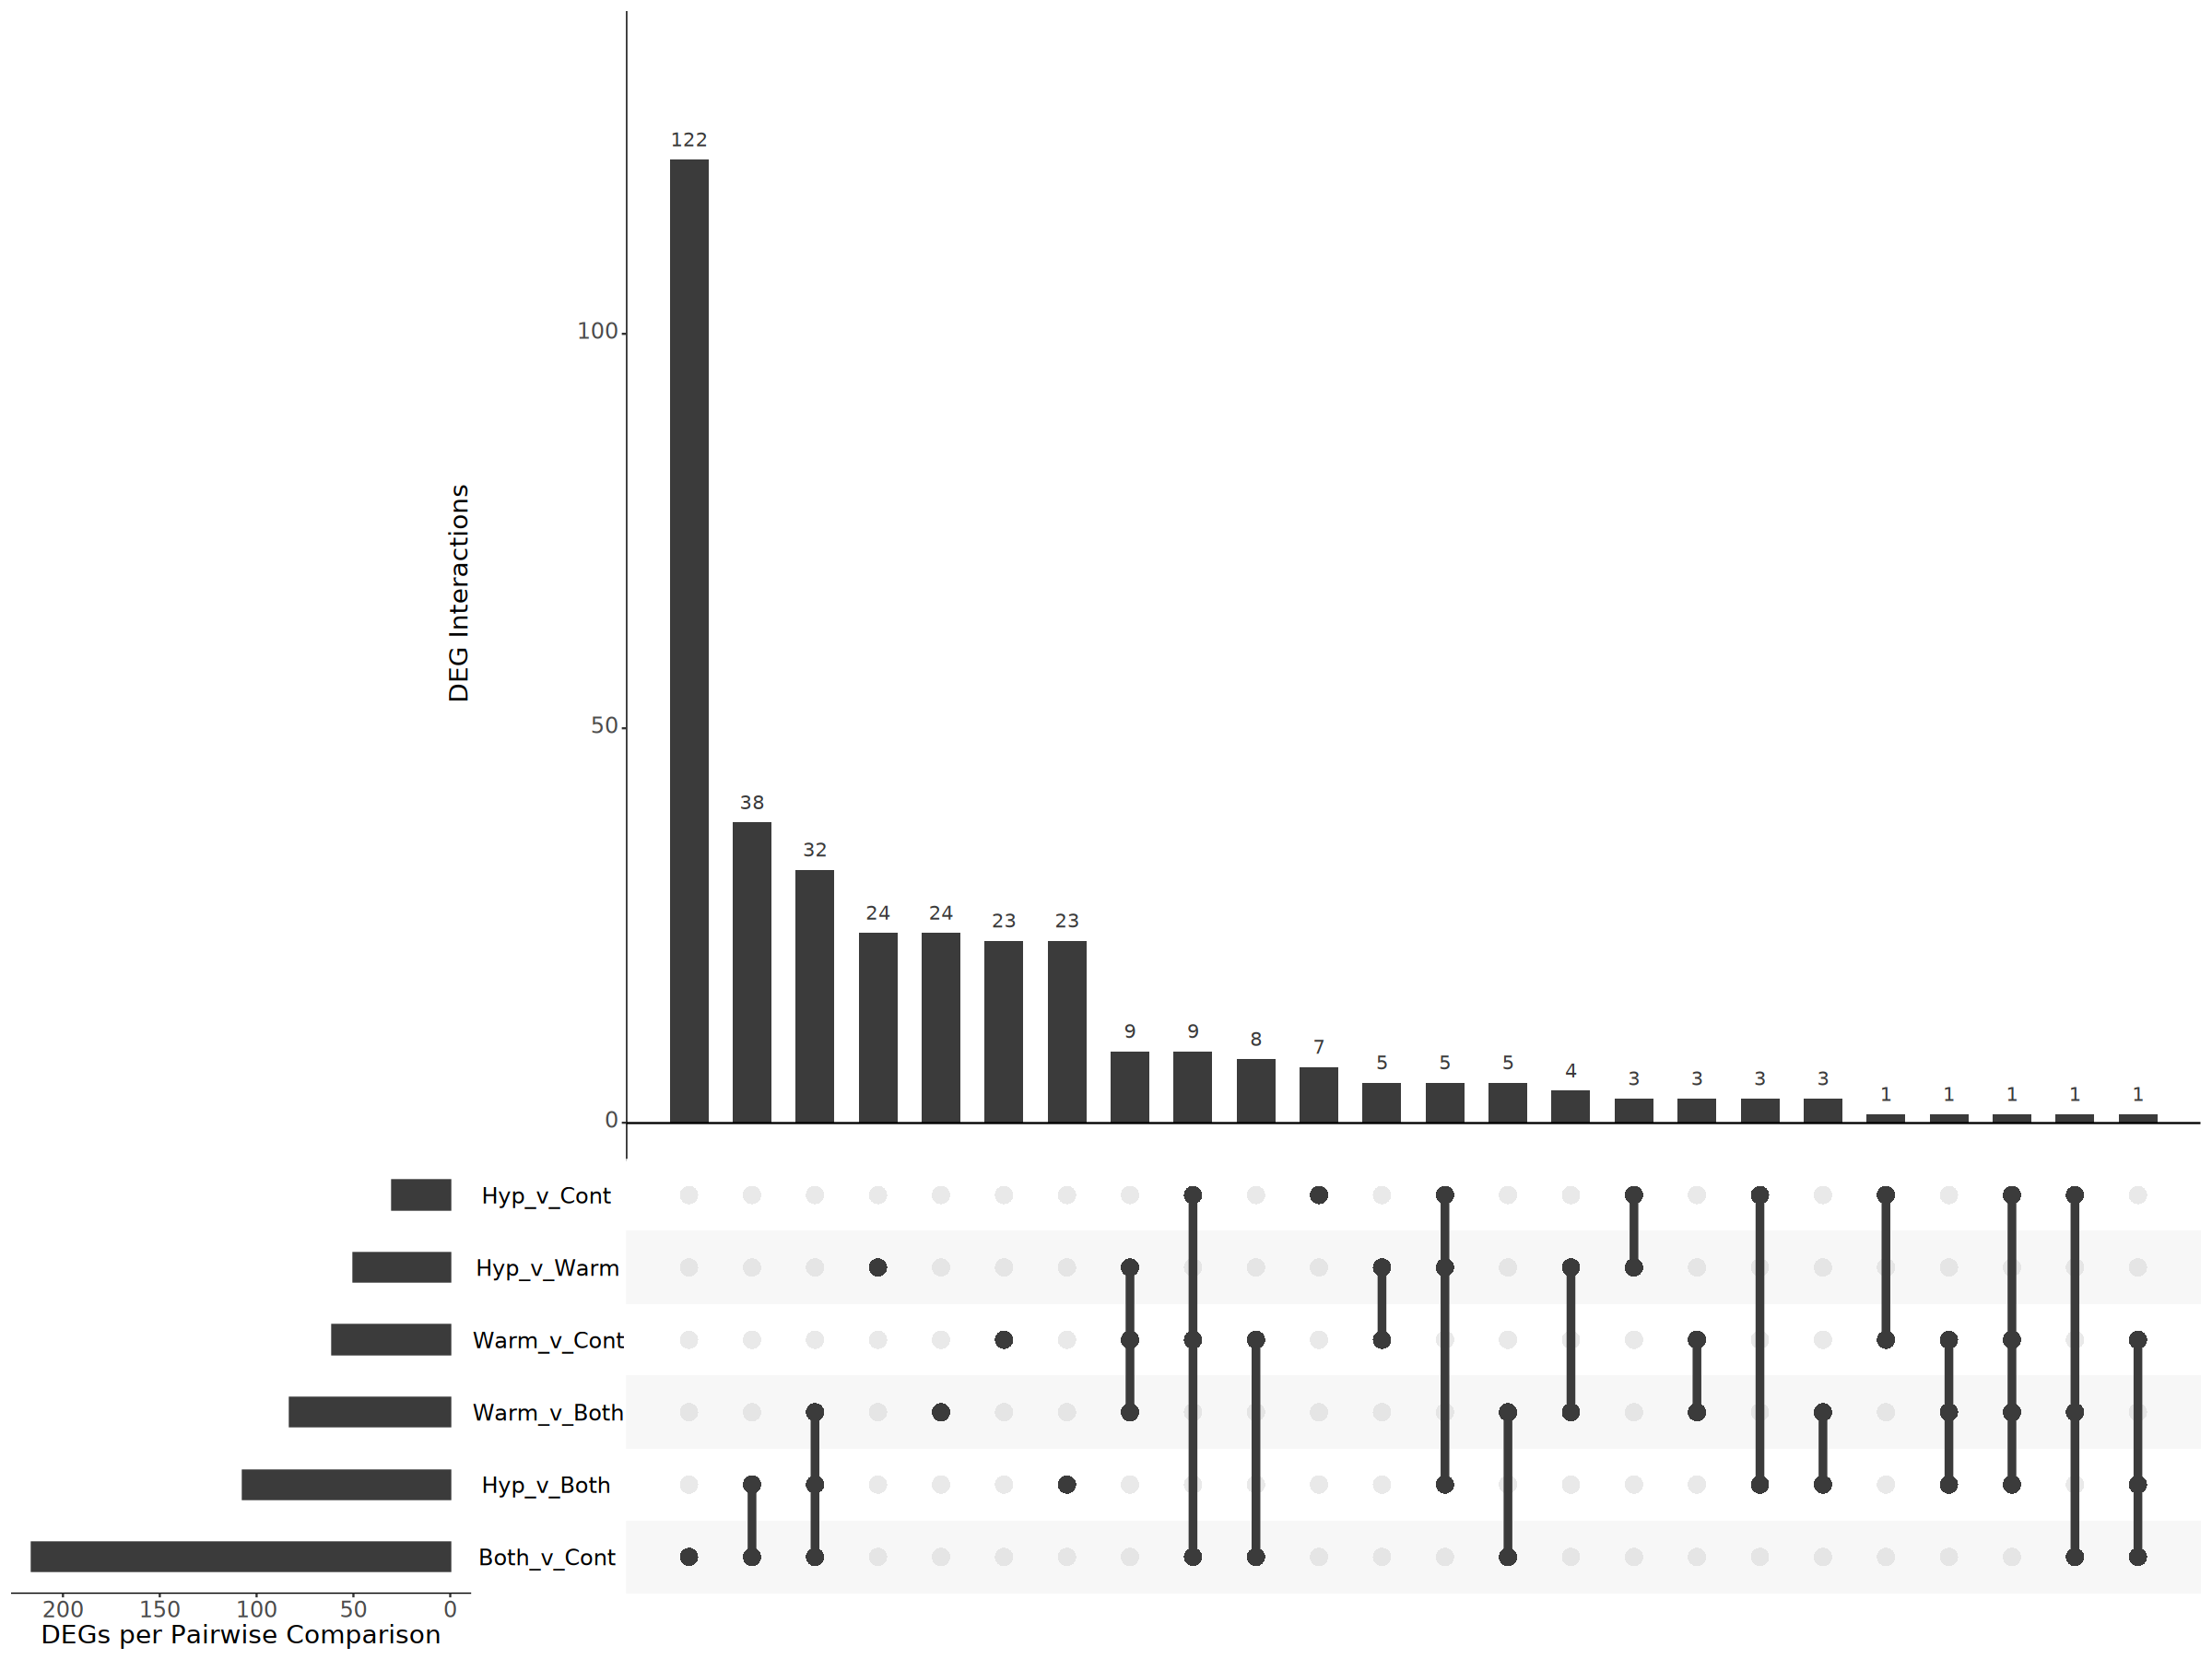

In [22]:
options(repr.plot.width=20, repr.plot.height=15)

all.comp.upset <- upset(fromList(u_list), nsets = 6,, order.by='freq', point.size = 5, line.size = 2, 
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Pairwise Comparison", 
    text.scale = c(2, 2, 2, 2, 2, 2))

all.comp.upset

# I STOPPED HERE

The above plot is every comparison I have, which can be helpful to look at the data all at once, but overwhelming too - splitting this up below to look at just **comparisons with control** ...

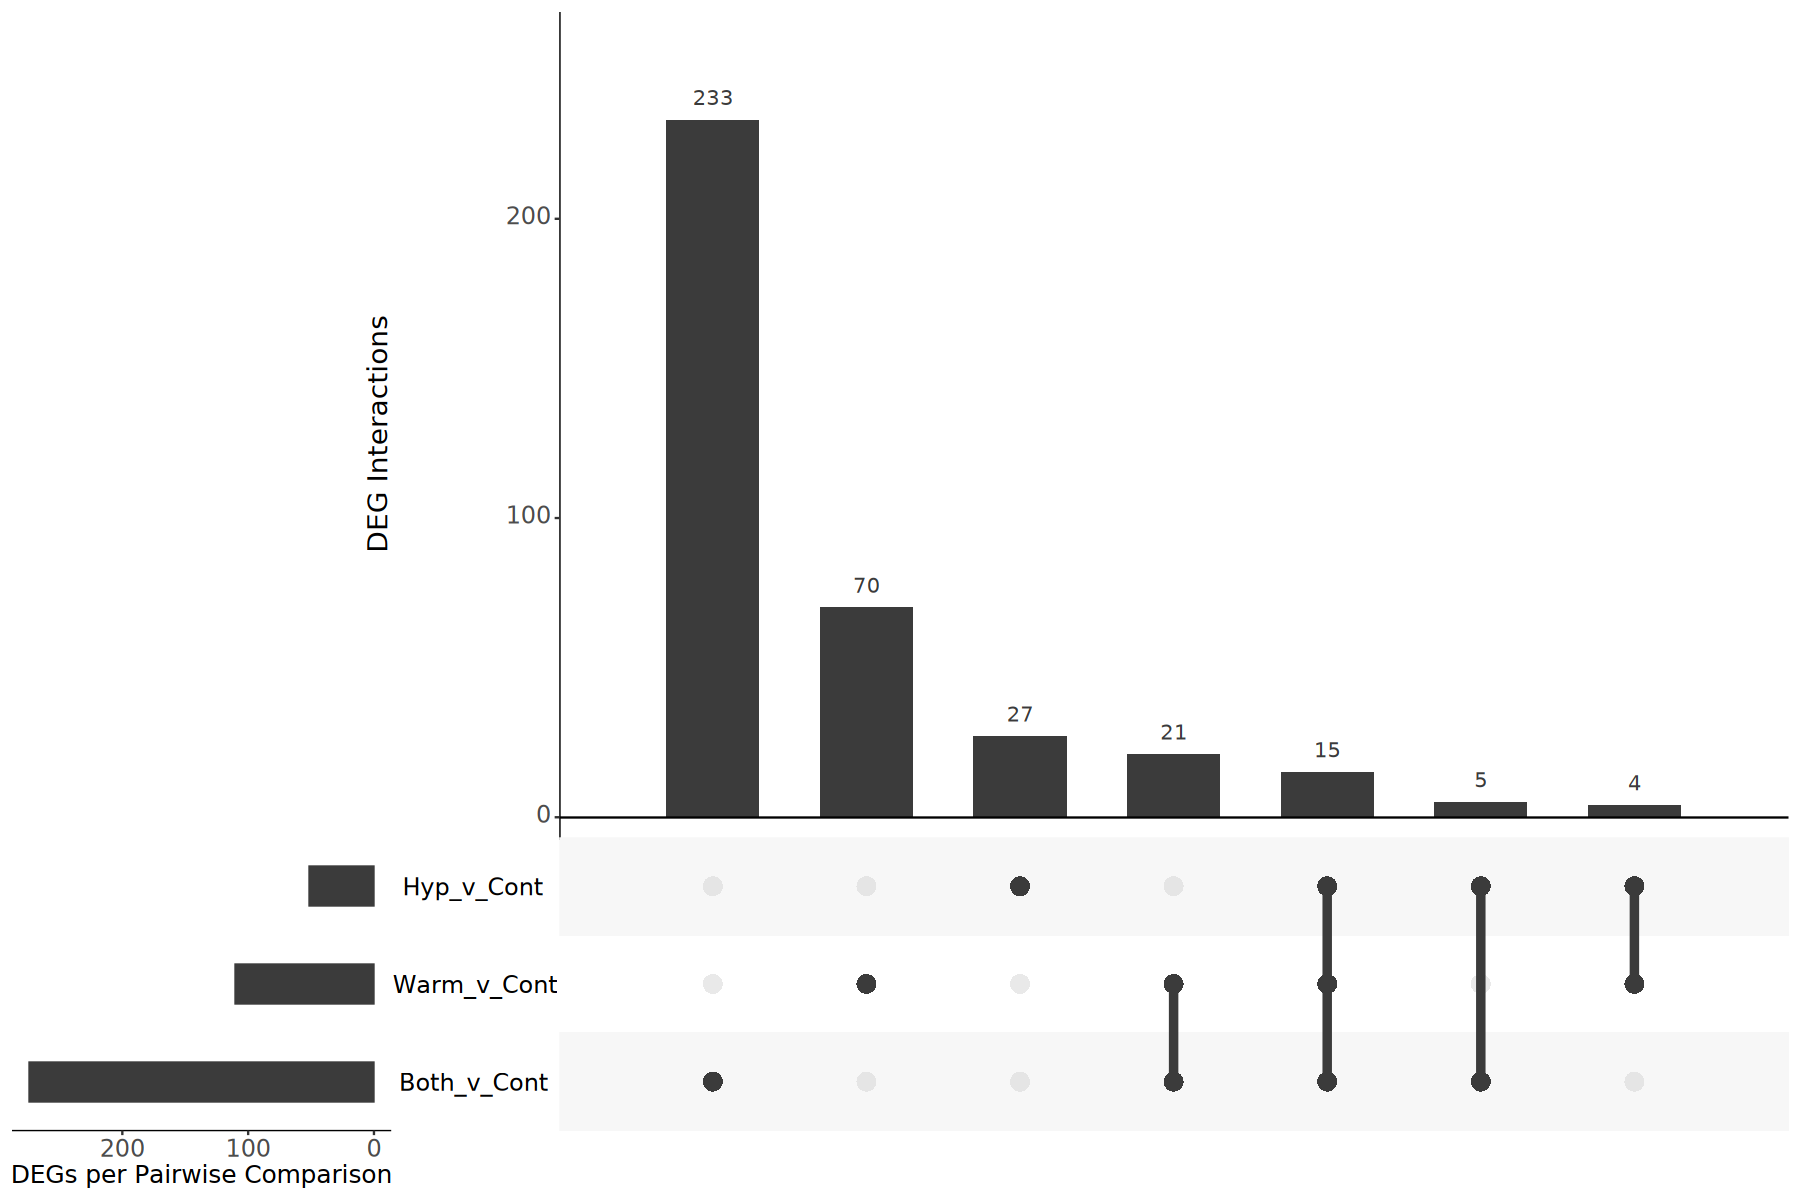

In [37]:
options(repr.plot.width=15, repr.plot.height=10)


# make list of dfs
cont_list = list(Warm_v_Cont = deg_list$w_c$X,
         Both_v_Cont = deg_list$b_c$X,
         Hyp_v_Cont = deg_list$h_c$X)

cont_upset <- upset(fromList(cont_list), nsets = 6,, order.by='freq', point.size = 5, line.size = 2, 
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Pairwise Comparison", 
    text.scale = c(2, 2, 1.75, 2, 2, 2))

cont_upset

In [38]:
pdf('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/plots/vs.cont_upset.pdf', width=15, height=10)
cont_upset
dev.off()

png 
  2

... and **other comparisons outside those with control**

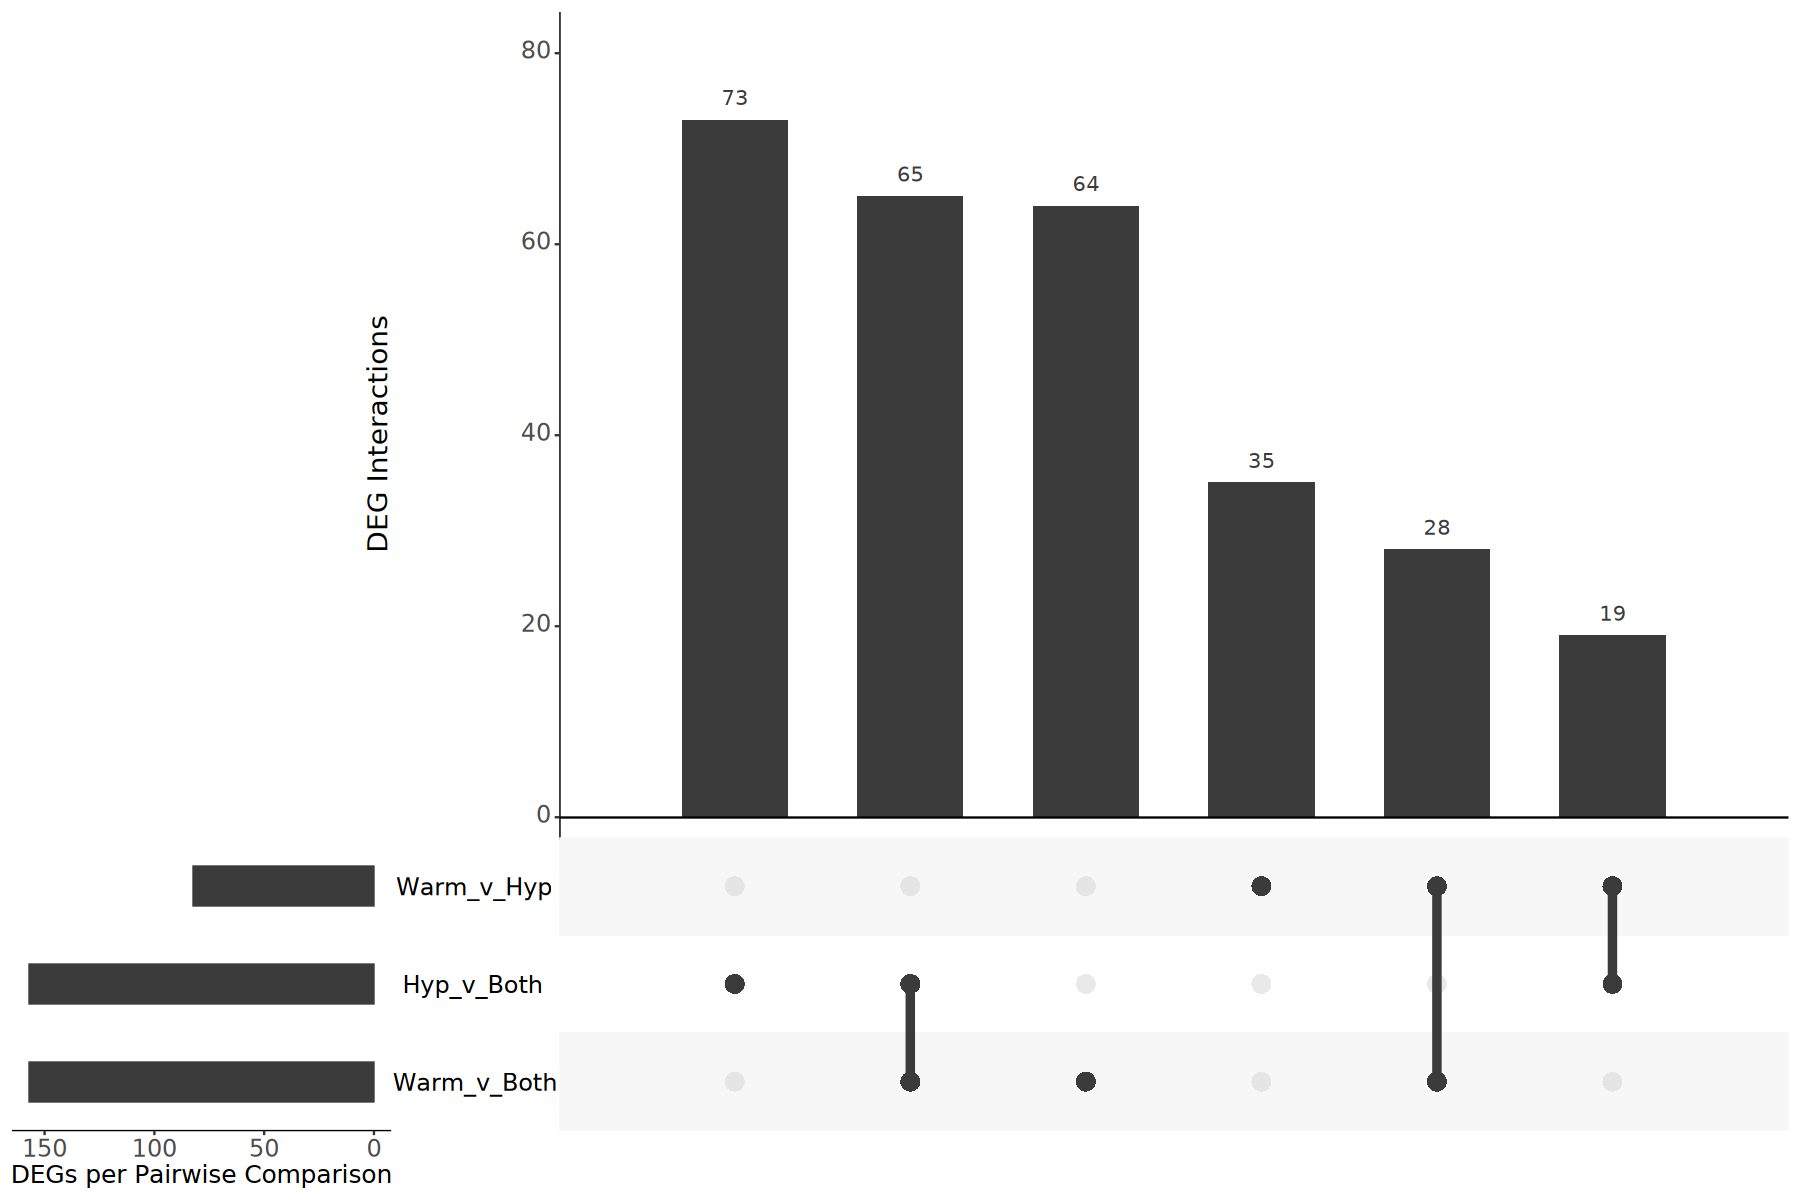

In [40]:
options(repr.plot.width=15, repr.plot.height=10)

other_list = list(Hyp_v_Both = deg_list$h_b$X,
                  Warm_v_Both = deg_list$w_b$X,
                  Warm_v_Hyp = deg_list$h_w$X)

other_upset <- upset(fromList(other_list), nsets = 6,, order.by='freq', point.size = 5, line.size = 2, 
    mainbar.y.label = "DEG Interactions", sets.x.label = "DEGs per Pairwise Comparison", 
    text.scale = c(2, 2, 1.75, 2, 2, 2))

other_upset

In [44]:
pdf('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase1_v_phase1/plots/vs.other_upset.pdf', width=15, height=10)
other_upset
dev.off()

png 
  2